<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [11]:
import sys
import matplotlib.pyplot as plt
print(sys.executable)


/Users/yannistally/projet_six/bin/python


In [12]:
#Importation de la librairie Pandas
import pandas as pd

In [13]:
#Importation de la librairie plotly express
import plotly.express as px


In [14]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir, dans Google, les mots clés "display all columns dataframe Pandas", par exemple.
#Dans les résultats de la recherche, privilégiez les solutions provenants de Stack Overflow ou Medium

pd.set_option('display.max_columns', None)


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [15]:

#Importation du fichier web.xlsx
df_web = pd.read_excel("/Users/yannistally/Documents/OpenClassrooms/Projet6/Data+Bottleneck (1)/web.xlsx")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel("/Users/yannistally/Documents/OpenClassrooms/Projet6/Data+Bottleneck (1)/erp.xlsx")
#importation du fichier liaison.xlsx
df_liaison  = pd.read_excel("/Users/yannistally/Documents/OpenClassrooms/Projet6/Data+Bottleneck (1)/liaison.xlsx")


/Users/yannistally/projet_six/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/yannistally/projet_six/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/yannistally/projet_six/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [16]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [17]:
#Consulter le nombre de colonnes
print(len(df_erp.columns))
#La nature des données dans chacune des colonnes
print(type(df_erp.columns))
#Le nombre de valeurs présentes dans chacune des colonnes
print(df_erp.count())


6
<class 'pandas.core.indexes.base.Index'>
product_id        825
onsale_web        825
price             825
stock_quantity    825
stock_status      825
purchase_price    825
dtype: int64


In [18]:
#Afficher les 5 premières lignes de la table
df_erp.head(5)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [19]:
#Vérifier si il y a les lignes en doublons dans la colonne product_id
doublon_product_id = df_erp.duplicated(subset='product_id')

print(df_erp[doublon_product_id])


Empty DataFrame
Columns: [product_id, onsale_web, price, stock_quantity, stock_status, purchase_price]
Index: []


In [20]:
#Afficher les valeurs distinctes de la colonne stock_status
#À quelle(s) autre(s) colonne(s) sont-elles liées ?

val_distc_stock_status = df_erp['stock_status'].unique()
print(val_distc_stock_status)
print("")
print(df_erp.head(5))
print("")
print('Elles sont liées à stock_quantity et product_id ')


['instock' 'outofstock']

   product_id  onsale_web  price  stock_quantity stock_status  purchase_price
0        3847           1   24.2              16      instock           12.88
1        3849           1   34.3              10      instock           17.54
2        3850           1   20.8               0   outofstock           10.64
3        4032           1   14.1              26      instock            6.92
4        4039           1   46.0               3   outofstock           23.77

Elles sont liées à stock_quantity et product_id 


In [21]:
#Création d'une colonne "stock_status_2
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#si la valeur de la colonne "stock_quantity" est nulle renseigner "outofstock" sinon mettre "instock"

df_erp["stock_status_2"] = "instock"


df_erp["stock_status_2"] = df_erp["stock_quantity"].apply(lambda x: "outofstock" if x <= 0 else "instock")

display(df_erp.head(5))



,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
0,3847,1,24.2,16,instock,12.88,instock
1,3849,1,34.3,10,instock,17.54,instock
2,3850,1,20.8,0,outofstock,10.64,outofstock
3,4032,1,14.1,26,instock,6.92,instock
4,4039,1,46.0,3,outofstock,23.77,instock


In [22]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
comparaison_col = df_erp["stock_status"] == df_erp["stock_status_2"]

print(comparaison_col)

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

0       True
1       True
2       True
3       True
4      False
       ...  
820     True
821     True
822     True
823     True
824     True
Length: 825, dtype: bool


In [23]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset

com_sum = 0
for element_true_false in comparaison_col:
    if element_true_false == True:
        com_sum += 1
    else:
        com_sum += 0

print(com_sum)

823


In [24]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3

df_erp["colone_identique"] = comparaison_col

display(df_erp.loc[df_erp["colone_identique"]== False])

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2,colone_identique
4,4039,1,46.0,3,outofstock,23.77,instock,False
398,4885,1,18.7,0,instock,9.66,outofstock,False


In [25]:
#Corriger la ou les données incohérentes

df_erp.iloc[4,4] = 'instock'
df_erp.iloc[398,4] = 'outofstock'


#Verification en utilisant le même code que plus haut pour afficher les problemes
display(df_erp.loc[df_erp["colone_identique"]== False])


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2,colone_identique
4,4039,1,46.0,3,instock,23.77,instock,False
398,4885,1,18.7,0,outofstock,9.66,outofstock,False


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [26]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatif ou nul?

prix_non_renseigne = df_erp["price"].isnull().sum()
print(prix_non_renseigne)
print(" ")
prix_negatif = df_erp[df_erp["price"]<=0]
display(prix_negatif)
print(" ")

#Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombres d'article avec un prix non renseignés: {}".format(prix_non_renseigne)) #Saisir l'instruction manquante dans la fonction format
print(" ")
#Afficher le prix minimum de la colonne "price"
prix_minimum =  df_erp['price'].min()
#Afficher le prix maximum de la colonne "price"
prix_maximum =  df_erp['price'].max()
print("Le prix minimum est de {} Euros et le prix maximum est de {} Euros".format(prix_minimum, prix_maximum))
print(" ")
#Affichier les prix inférieurs à 0 (qu'est ce qu'il faut en faire ?)
print('Il faut vérifier avec les commerciaux pour voir quelle correction apporter aux prix. \n Est ce juste une erreur de symbole ou un prix totalement différent ?' )

0
 


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2,colone_identique
151,4233,0,-20.0,0,outofstock,10.33,outofstock,True
469,5017,0,-8.0,0,outofstock,4.34,outofstock,True
739,6594,0,-9.1,19,instock,4.61,instock,True


 
Nombres d'article avec un prix non renseignés: 0
 
Le prix minimum est de -20.0 Euros et le prix maximum est de 225.0 Euros
 
Il faut vérifier avec les commerciaux pour voir quelle correction apporter aux prix. 
 Est ce juste une erreur de symbole ou un prix totalement différent ?


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [27]:
#######################
### stock_quantity  ###
#######################
#Vérification de la colonne stock quantity
#Afficher la quantité minimum de la colonne "stock_quantity"
quantite_minimum =  df_erp['stock_quantity'].min()

#Afficher la quantité maximum de la colonne "stock_quantity"
quantite_maximum =  df_erp['stock_quantity'].max()

print("La quantité minimum est de {} et le quantité maximum est de {} ".format(quantite_minimum, quantite_maximum))

#Affichier les stocks inférieurs à 0 (qu'est ce qu'il faut en faire ?)
quantite_negatif = df_erp[df_erp["stock_quantity"]<0]
display(quantite_negatif)

print('Il faut vérifier avec nos logisticiens à quoi correspond les stocks négatifs\n est ce des produits vendus et dont la production n\'a pas été terminée et les mettre à zéro si la réponse n\'est pas satisfaisante' )

La quantité minimum est de -10 et le quantité maximum est de 145 


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2,colone_identique
449,4973,0,10.0,-10,outofstock,4.96,outofstock,True
573,5700,1,44.5,-1,outofstock,22.30,outofstock,True


Il faut vérifier avec nos logisticiens à quoi correspond les stocks négatifs
 est ce des produits vendus et dont la production n'a pas été terminée et les mettre à zéro si la réponse n'est pas satisfaisante


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [28]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient? Que signifient-elles?
onsale_minimum =  df_erp['onsale_web'].min()
onsale_maximum =  df_erp['onsale_web'].max()
print("Le  onsale_web minimum est de {} et le s onsale_web maximum est de {} ".format(onsale_minimum, onsale_maximum))

onsale_negatif = df_erp[df_erp["onsale_web"]<0]
display(onsale_negatif)

print('Cette colonne indique 0 si le produit est indisponible sur internet et 1 si il est disponible sur internet')


Le  onsale_web minimum est de 0 et le s onsale_web maximum est de 1 


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2,colone_identique


Cette colonne indique 0 si le produit est indisponible sur internet et 1 si il est disponible sur internet


In [29]:
#Quelles sont les colonnes à conserver selon vous?
print('Selon moi il ne faut pas conserver stock_status, stock_status_2, colone_identique ')

Selon moi il ne faut pas conserver stock_status, stock_status_2, colone_identique 


In [30]:
#Supprimer la colonnecomportant le libellé "stock_status_2" car elle est redondante 
#avec la colonne "stock_status".

df_erp = df_erp.drop("stock_status_2", axis='columns')
df_erp = df_erp.drop("colone_identique", axis='columns')


display(df_erp)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,instock,23.77
...,...,...,...,...,...,...
820,7203,0,45.0,30,instock,23.48
821,7204,0,45.0,9,instock,24.18
822,7247,1,54.8,6,instock,27.18
823,7329,0,26.5,14,instock,13.42


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [31]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price : 
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
achat_non_renseigne = df_erp["purchase_price"].isnull().sum()
print(achat_non_renseigne)
#Afficher le prix minimum de la colonne "purchase_price"
purchase_price_minimum =  df_erp['purchase_price'].min()

#Afficher le prix maximum de la colonne "purchase_price"
purchase_price_maximum =  df_erp['purchase_price'].max()

print("Le prix d'achat minimum est de {} et le prix d'achat maximum est de {} ".format(purchase_price_minimum, purchase_price_maximum))


0
Le prix d'achat minimum est de 2.74 et le prix d'achat maximum est de 137.81 


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>
 

In [32]:
#Dimension du dataset
#Nombre d'observations
print("Le tableau comporte {} observation(s) ou article(s)".format(df_web.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_web.shape[1]))
#Nombre de caractéristiques


Le tableau comporte 1513 observation(s) ou article(s)
Le tableau comporte 29 colonne(s)


In [33]:
#Consulter le nombre de colonnes
print(len(df_web.columns))
#La nature des données dans chacune des colonnes
print(type(df_web.columns))
#Le nombre de valeurs présentes dans chacune des colonnes
display(df_web.count())


29
<class 'pandas.core.indexes.base.Index'>


sku                      1428
virtual                  1513
downloadable             1513
rating_count             1513
average_rating           1430
total_sales              1430
tax_status                716
tax_class                   0
post_author              1430
post_date                1430
post_date_gmt            1430
post_content                0
product_type             1429
post_title               1430
post_excerpt              716
post_status              1430
comment_status           1430
ping_status              1430
post_password               0
post_name                1430
post_modified            1430
post_modified_gmt        1430
post_content_filtered       0
post_parent              1430
guid                     1430
menu_order               1430
post_type                1430
post_mime_type            714
comment_count            1430
dtype: int64

In [34]:
#Selon vous, quelles sont les colonnes à conserver ?
print("Les colonnes à ne pas conserver sont tax_class, post_content, post_password et post_content_filtered")

Les colonnes à ne pas conserver sont tax_class, post_content, post_password et post_content_filtered


In [35]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
df_web = df_web.drop(["tax_class", "post_content", "post_password", "post_content_filtered"], axis=1)

In [36]:
#Visualisation des valeurs de la colonne sku
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?

display(df_web.head(5))

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
0,11862,0,0,0,0.0,3.0,NaN,2.0,2018-02-12 13:46:23,2018-02-12 12:46:23,Vin,Gilles Robin Hermitage Rouge 2012,NaN,publish,closed,closed,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1,16057,0,0,0,0.0,5.0,NaN,2.0,2018-04-17 15:29:17,2018-04-17 13:29:17,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...,NaN,publish,closed,closed,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 10:05:02,2020-07-07 08:05:02,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
2,14692,0,0,0,0.0,5.0,taxable,2.0,2019-03-19 10:06:47,2019-03-19 09:06:47,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,<div>Grâce à la complémentarité des 3 cépages ...,publish,closed,closed,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
3,16295,0,0,0,0.0,14.0,NaN,2.0,2018-02-15 14:05:06,2018-02-15 13:05:06,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,NaN,publish,closed,closed,moulin-de-gassac-igp-pays-dherault-guilhem-ros...,2020-08-27 18:55:03,2020-08-27 16:55:03,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
4,15328,0,0,0,0.0,2.0,taxable,2.0,2019-03-27 18:05:09,2019-03-27 17:05:09,Vin,Agnès Levet Côte Rôtie Maestria 2017,"<span style=""float: none; background-color: tr...",publish,closed,closed,agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


In [37]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les?

# La on a fait une boucle pour trouver les sku différent car grace .info() on sait que sku ne contient pas que des int 
# La boucle permet d'extraire chaque valeur étant de type str, et nous a permis de voir qu'il y'a des lignes mal remplies

sku_liste = df_web.iloc[:, 0]
sku_liste_wrong =[]

for x in sku_liste:
    if type(x) == str:
        sku_liste_wrong.append(x)
    else:
       continue

print(sku_liste_wrong)

def_sku_wrong = df_web[df_web['sku'].isin(sku_liste_wrong)]

display(def_sku_wrong)

['13127-1', 'bon-cadeau-25-euros', '13127-1', 'bon-cadeau-25-euros']


,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
272,13127-1,0,0,0,0.0,4.0,taxable,2.0,2020-06-09 15:42:04,2020-06-09 13:42:04,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,"Nez gracieux, très élégant avec une touche flo...",publish,closed,closed,clos-du-mont-olivet-chateauneuf-du-pape-2007-2,2020-07-20 17:09:06,2020-07-20 15:09:06,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
842,bon-cadeau-25-euros,0,0,0,0.0,7.0,NaN,1.0,2018-06-01 13:53:46,2018-06-01 11:53:46,Autre,Bon cadeau de 25€,NaN,publish,closed,closed,bon-cadeau-de-25-euros,2018-06-01 14:13:57,2018-06-01 12:13:57,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1117,13127-1,0,0,0,0.0,4.0,NaN,2.0,2020-06-09 15:42:04,2020-06-09 13:42:04,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,NaN,publish,closed,closed,clos-du-mont-olivet-chateauneuf-du-pape-2007-2,2020-07-20 17:09:06,2020-07-20 15:09:06,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1387,bon-cadeau-25-euros,0,0,0,0.0,7.0,taxable,1.0,2018-06-01 13:53:46,2018-06-01 11:53:46,NaN,Bon cadeau de 25€,"<span style=""color: #a85253;""><strong>Parlons ...",publish,closed,closed,bon-cadeau-de-25-euros,2018-06-01 14:13:57,2018-06-01 12:13:57,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


In [38]:
#Identifier les lignes sans code articles

sku_nan = df_web[df_web['sku'].isnull()]
print(sku_nan)


      sku  virtual  downloadable  rating_count  average_rating  total_sales  \
8     NaN        0             0             0             NaN          NaN   
20    NaN        0             0             0             NaN          NaN   
30    NaN        0             0             0             NaN          NaN   
37    NaN        0             0             0             NaN          NaN   
41    NaN        0             0             0             NaN          NaN   
...   ...      ...           ...           ...             ...          ...   
1384  NaN        0             0             0             NaN          NaN   
1429  NaN        0             0             0             NaN          NaN   
1432  NaN        0             0             0             NaN          NaN   
1445  NaN        0             0             0             NaN          NaN   
1457  NaN        0             0             0             NaN          NaN   

     tax_status  post_author post_date post_date_gm

In [39]:
#Pour les codes articles identifiés, réalisé une analyse et définissez l'action à entreprendre
# display(sku_nan.info())

# TODO mettre article inconnu au lieu de NaN
sku_nan['sku'].fillna('Article inconnu', inplace=True)
display(sku_nan[~ sku_nan['average_rating'].isna()])

print("Je pense qu'il faut demander aux commerciaux et aux logisticiens pourquoi il n'ya pas de référence et les ventes sont négatives ")


/var/folders/jb/gy4cdzrd21j4lh00kfz13l3c0000gn/T/ipykernel_58440/1052496399.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sku_nan['sku'].fillna('Article inconnu', inplace=True)
/var/folders/jb/gy4cdzrd21j4lh00kfz13l3c0000gn/T/ipykernel_58440/1052496399.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sku_nan['sku'].fillna('Article inc

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
1084,Article inconnu,0,0,0,0.0,-56.0,taxable,2.0,2018-08-08 11:23:43,2018-08-08 09:23:43,Vin,Pierre Jean Villa Condrieu Jardin Suspendu 2018,"<span id=""u1194-83"">Le nez séduit par ses parf...",publish,closed,closed,pierre-jean-villa-condrieu-suspendu-2018,2019-11-02 13:24:01,2019-11-02 12:24:01,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
1087,Article inconnu,0,0,0,0.0,-17.0,taxable,2.0,2018-07-31 12:07:23,2018-07-31 10:07:23,Vin,Pierre Jean Villa Côte Rôtie Fongeant 2017,"Fongeant 2017 explose sur un fruit brillant, p...",publish,closed,closed,pierre-jean-villa-cote-rotie-fongeant-2017,2019-11-02 13:24:15,2019-11-02 12:24:15,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


Je pense qu'il faut demander aux commerciaux et aux logisticiens pourquoi il n'ya pas de référence et les ventes sont négatives 


In [40]:
#La clé pour chaque ligne est-elle uniques? ou autrement dit, y a-t-il des doublons?

df_web.dropna(how='all', inplace=True)
#Vérification de la présence de doublons
doublon_sku = df_web.duplicated(subset='sku')
print("Il y'a {} doublons dans la colonne sku".format(doublon_sku.sum()))
#Afficher les lignes en doublon
display(df_web[df_web.duplicated()])


Il y'a 798 doublons dans la colonne sku


,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
20,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
30,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
37,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
41,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
47,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1429,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1432,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1445,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
# Differencier la bonne ligne de la mauvaise et dire celle qui n'est pas necessaire

print("On supprime les lignes avec attachment car elle ne sont exploitables se sont des image")

df_web.drop(df_web[df_web["post_type"] == 'attachment'].index, inplace=True)


# TODO FILTRER TOUT le DATA FRAME et supp les NaN sans oublier de renommer les articles non reconnus  
df_web['sku'].fillna('Article inconnu', inplace=True)

display(df_web[df_web['sku'] == 'Article inconnu'])


On supprime les lignes avec attachment car elle ne sont exploitables se sont des image


/var/folders/jb/gy4cdzrd21j4lh00kfz13l3c0000gn/T/ipykernel_58440/1077728964.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_web['sku'].fillna('Article inconnu', inplace=True)


,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
8,Article inconnu,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
20,Article inconnu,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
30,Article inconnu,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
37,Article inconnu,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
41,Article inconnu,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384,Article inconnu,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1429,Article inconnu,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1432,Article inconnu,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1445,Article inconnu,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
#Les lignes sans code article semble être toutes non renseignés
#Pour s'en assurer réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
sku_nan = df_web.loc[df_web['sku']== 'Article inconnu']
#2 - utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeur reseigner dans chacune des colonnes
sku_nan.info()
#3 - Que constatez-vous?
display(sku_nan[sku_nan['average_rating'].notna()])

df_web.drop(df_web[df_web['average_rating'].isna()].index, inplace=True)


<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, 8 to 1457
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sku                85 non-null     object        
 1   virtual            85 non-null     int64         
 2   downloadable       85 non-null     int64         
 3   rating_count       85 non-null     int64         
 4   average_rating     2 non-null      float64       
 5   total_sales        2 non-null      float64       
 6   tax_status         2 non-null      object        
 7   post_author        2 non-null      float64       
 8   post_date          2 non-null      datetime64[ns]
 9   post_date_gmt      2 non-null      datetime64[ns]
 10  product_type       2 non-null      object        
 11  post_title         2 non-null      object        
 12  post_excerpt       2 non-null      object        
 13  post_status        2 non-null      object        
 14  comment_status 

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
1084,Article inconnu,0,0,0,0.0,-56.0,taxable,2.0,2018-08-08 11:23:43,2018-08-08 09:23:43,Vin,Pierre Jean Villa Condrieu Jardin Suspendu 2018,"<span id=""u1194-83"">Le nez séduit par ses parf...",publish,closed,closed,pierre-jean-villa-condrieu-suspendu-2018,2019-11-02 13:24:01,2019-11-02 12:24:01,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
1087,Article inconnu,0,0,0,0.0,-17.0,taxable,2.0,2018-07-31 12:07:23,2018-07-31 10:07:23,Vin,Pierre Jean Villa Côte Rôtie Fongeant 2017,"Fongeant 2017 explose sur un fruit brillant, p...",publish,closed,closed,pierre-jean-villa-cote-rotie-fongeant-2017,2019-11-02 13:24:15,2019-11-02 12:24:15,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


In [43]:
display(df_web[df_web['sku'] == 'Article inconnu'])


,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
1084,Article inconnu,0,0,0,0.0,-56.0,taxable,2.0,2018-08-08 11:23:43,2018-08-08 09:23:43,Vin,Pierre Jean Villa Condrieu Jardin Suspendu 2018,"<span id=""u1194-83"">Le nez séduit par ses parf...",publish,closed,closed,pierre-jean-villa-condrieu-suspendu-2018,2019-11-02 13:24:01,2019-11-02 12:24:01,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
1087,Article inconnu,0,0,0,0.0,-17.0,taxable,2.0,2018-07-31 12:07:23,2018-07-31 10:07:23,Vin,Pierre Jean Villa Côte Rôtie Fongeant 2017,"Fongeant 2017 explose sur un fruit brillant, p...",publish,closed,closed,pierre-jean-villa-cote-rotie-fongeant-2017,2019-11-02 13:24:15,2019-11-02 12:24:15,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [44]:
#Dimension du dataset
#Nombre d'observations
print("Le tableau comporte {} observation(s) ou article(s)".format(df_liaison.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_liaison.shape[1]))
#Nombre de caractéristiques


Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 2 colonne(s)


In [45]:
#Consulter le nombre de colonnes
print(len(df_liaison.columns))
#La nature des données dans chacune des colonnes
print(type(df_liaison.columns))
#Le nombre de valeurs présentes dans chacune des colonnes
print(df_liaison.count())

2
<class 'pandas.core.indexes.base.Index'>
id_web        734
product_id    825
dtype: int64


In [46]:
#Les valeurs de la colonne "product_id" sont elles toutes uniques?

doublon_pid = df_liaison['product_id'].duplicated().sum()

print(f'Il y\'a {doublon_pid} doublon')

Il y'a 0 doublon


In [47]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques? VOIR ISNULL 
doublon_idweb = df_liaison['id_web'].isnull().sum()
print(f'Il y\'a {doublon_idweb} doublons')



Il y'a 91 doublons


In [48]:
#Avons-nous des articles sans correspondances? 

display(df_liaison.info())

display(df_liaison.isna().sum())

print("oui il y'a 91 lignes sans correspondances dans la colonne id_web")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


None

id_web        91
product_id     0
dtype: int64

oui il y'a 91 lignes sans correspondances dans la colonne id_web


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [49]:
display(df_liaison)

,id_web,product_id
0,15298,3847
1,15296,3849
2,15300,3850
3,19814,4032
4,19815,4039
...,...,...
820,NaN,7203
821,NaN,7204
822,13127-1,7247
823,14680-1,7329


In [50]:
#Fusion des fichiers df_erp et df_liaison

df_erp_liaison = pd.merge(df_erp, df_liaison, left_on='product_id', right_on='product_id', indicator=True) 

display(df_erp_liaison)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge
0,3847,1,24.2,16,instock,12.88,15298,both
1,3849,1,34.3,10,instock,17.54,15296,both
2,3850,1,20.8,0,outofstock,10.64,15300,both
3,4032,1,14.1,26,instock,6.92,19814,both
4,4039,1,46.0,3,instock,23.77,19815,both
...,...,...,...,...,...,...,...,...
820,7203,0,45.0,30,instock,23.48,NaN,both
821,7204,0,45.0,9,instock,24.18,NaN,both
822,7247,1,54.8,6,instock,27.18,13127-1,both
823,7329,0,26.5,14,instock,13.42,14680-1,both


In [51]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?

print(df_erp_liaison['_merge'].value_counts())

print('non')


_merge
both          825
left_only       0
right_only      0
Name: count, dtype: int64
non


In [52]:
df_erp_liaison = df_erp_liaison.drop(columns=['_merge'])


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [53]:
#Fusionnez les datasets df_merge et df_web

df_merge_web = pd.merge(df_erp_liaison, df_web, left_on='id_web', right_on='sku', how='outer', indicator=True)

# Trie et suppression des doubons
# Méthode trie sur le posttype afin d'avoir "attachment" toujours en premier de sorte 
# que lorsque j'effectue le drop dupplicate je peux faire un keep last afin de garder les lignes n'ayant pas attachment 
df_merge_web_sort = df_merge_web.sort_values(by='post_type', ascending=True)
df_merge_web_sort.drop_duplicates(subset=['product_id'], keep='last', inplace=True )
df_merge_web_sort.sort_values(by='product_id', ascending=True, inplace=True)

# pour la suite on convertie pour pas changer tout mon code en quelque sorte le df non nettoyé en celui nettoyé
df_merge_web = df_merge_web_sort

In [54]:
#Avons-nous des lignes sans correspondances?
# TODO je dois avoir 113 lignes sans correspondances 

display(df_merge_web['_merge'].value_counts())
display("Oui il y'a 20 valeurs dont la liaison est fait par un 'left onfly' ")

_merge
both          714
left_only     111
right_only      1
Name: count, dtype: int64

"Oui il y'a 20 valeurs dont la liaison est fait par un 'left onfly' "

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univarié des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

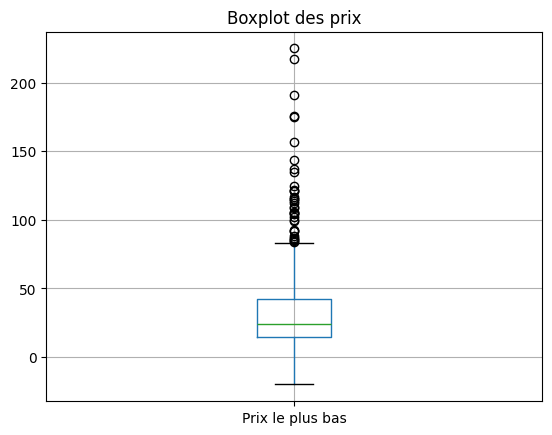

In [55]:
#Création d'une Boite à moustache de la répartition des prix grâce à Pandas

df_merge_web[["price"]].boxplot()
plt.title("Boxplot des prix") 
plt.gca().xaxis.set_ticklabels(['Prix le plus bas'])
plt.show()

In [56]:
#Autre méthode avec plotly express
import nbformat
df_merge_web_box = df_merge_web
# df_merge_web_box = px.data.tips()
fig = px.box(df_merge_web_box, y="price")
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utisation de méthodes statistique</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [57]:

print("\nNombre de valeurs dans la colonne 'price':", len(df_merge_web['price']))


Nombre de valeurs dans la colonne 'price': 826


In [58]:
#Calculer la moyenne du prix
moyenne_prix = df_merge_web['price'].mean()
print(f"La moyenne est de {moyenne_prix:.2f}")

#Calculer l'écart-type du prix
ecart_type_prix = df_merge_web['price'].std()
print(f"L'écart-type est de {ecart_type_prix:.2f}")

#Calculer le Z-score
# La cote Z correspond au nombre d'écarts types séparant 
# une donnée de la moyenne dans la distribution d’une variable aléatoire.
from scipy.stats import zscore
z_score_prix = zscore(df_merge_web['price'], nan_policy='omit')
print(z_score_prix)

La moyenne est de 32.19
L'écart-type est de 26.71
[-2.99210820e-01  7.91246745e-02 -4.26571284e-01 -6.77546315e-01
  5.17394505e-01  7.91246745e-02  1.91903387e-02 -3.69981012e-02
  1.04181994e+00  3.90034041e-01  1.79099914e+00 -5.20218684e-01
 -3.51653364e-01 -4.82759724e-01 -3.89112324e-01 -9.17283658e-01
  5.66492985e-02  4.53714273e-01  1.47634388e+00  2.01949880e+00
 -7.29988859e-01 -8.79824698e-01 -8.79824698e-01 -8.79824698e-01
 -7.59956027e-01 -7.59956027e-01 -6.62562731e-01 -6.66308627e-01
 -4.75267932e-01 -4.26571284e-01 -3.81620532e-01 -5.83898915e-01
  1.04181994e+00 -3.29177988e-01  3.79198186e-02 -7.03093326e-03
  1.70858943e+00 -7.29988859e-01 -6.55070939e-01 -6.79419263e-01
 -3.47907468e-01  4.42476585e-01  1.80263866e-01  2.55181786e-01
 -5.68915331e-01 -3.36669780e-01 -4.93997412e-01 -5.91390707e-01
 -6.66308627e-01  1.52878642e+00  5.54853465e-01 -6.92529899e-01
 -7.33734755e-01 -3.51653364e-01 -7.26242963e-01 -3.77874636e-01
 -7.26242963e-01 -6.13866083e-01 -6.1386

In [59]:
#Quel est le seuil prix dont z-score est supérieur à 3?

df_merge_web['z_score_prix'] = z_score_prix

# display(df_merge_web.loc[(df_merge_web['z_score_prix']>3) | (df_merge_web['z_score_prix']< -3)]) 

df_outlier = df_merge_web.loc[df_merge_web['z_score_prix'].abs()>3]
seuil_outlier = df_outlier['price'].min()

print(f"Le seuil prix dont le z-score est supérieur à 3 est de {seuil_outlier:.2f}")

Le seuil prix dont le z-score est supérieur à 3 est de 114.00


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'interval interquartile</h3>
</div>

In [60]:
#Utilisation de la fonction describe de Pandas pour l'etude des mesures de dispersions
df_merge_web['price'].describe()

count    825.000000
mean      32.187697
std       26.712077
min      -20.000000
25%       14.500000
50%       24.300000
75%       42.000000
max      225.000000
Name: price, dtype: float64

In [61]:
#Définissez un seuil pour les articles "outliers" en prix 

def detect_outlier(df_merge_web, column):
    Q1 = df_merge_web[column].quantile(0.25)
    Q3 = df_merge_web[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

lower_bound, upper_bound = detect_outlier(df_merge_web, 'price')
print(f"Seuil inférieur: {lower_bound:.2f}")
print(f"Seuil supérieur: {upper_bound:.2f}")

Seuil inférieur: -26.75
Seuil supérieur: 83.25


In [62]:
#

In [63]:
#Définissez le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
#  FILTRE NOMBRE OUTLINER PUIS APRES FAIRE PROPORTION
nbr_outliner = len(df_merge_web.loc[(df_merge_web['price'] > upper_bound) | (df_merge_web['price'] < lower_bound)])
print(nbr_outliner)


proportion_outliner = round((nbr_outliner / len(df_merge_web)) * 100, 2)
print( f"La proportion de outliers est de {proportion_outliner}%")

36
La proportion de outliers est de 4.36%


In [64]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_merge_web, x='product_type', y='price')

plt.title('Distribution des prix par type de produit')
plt.xlabel('Type de produit')
plt.ylabel('Prix')
plt.xticks(rotation=40)  # rotation des labels si trop longs
plt.tight_layout()
plt.show()

print('Je pense que cet outliner est justifié car il exclut vraiment les plus grands extrêmes et peut être vérifiable à travers la boite à moustache')

 

NameError: name 'sns' is not defined

In [ ]:
# #Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
# # TODO FAIRE plusieurs BOITE A MOUSTACHE avec les differentes catégories de produits 
# print('Je pense que cet outliner est justifié car il exclut vraiment les plus grands extrêmes et peut être vérifiable à travers la boite à moustache')

# numeric_cols = df_merge_web.select_dtypes(include='number').columns

# df_merge_web_type = df_merge_web.groupby('product_type')[numeric_cols].sum()

# display(df_merge_web_type)

# df_merge_web_type[["price"]].boxplot()
# plt.title("Boxplot des prix") 
# plt.gca().xaxis.set_ticklabels(['Prix le plus bas'])
# plt.show()

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univarié du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivarié  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [ ]:
display(df_merge_web['product_type'].unique())


array(['Vin', nan, 'Champagne', 'Whisky', 'Cognac', "Huile d'olive",
       'Gin'], dtype=object)

In [ ]:
##############################
# Calculer le CA du site web #
##############################

#Créez une colonne calculant le CA par article
df_merge_web['ca_par_article'] = (df_merge_web['price']* df_merge_web['total_sales'])
#Calculez la somme de la colonne "ca_par_article"
chiffre_affaires = df_merge_web['ca_par_article'].sum()
#Ce résultat correspond au chiffre d'affaire du site web
print(f"Le chiffre d'affaire du site web est de {chiffre_affaires} Euros")

Le chiffre d'affaire du site web est de 143680.1 Euros


In [ ]:
###############################
# Palmares des articles en CA #
###############################


#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
df_merge_web = df_merge_web.sort_values(by='ca_par_article', ascending=False)

# display(df_merge_web)
#Réinitialiser l'index du dataset par un reset_index
df_merge_web.reset_index(drop=True, inplace=True)
#Afficher les 20 premier articles en CA
top_20 = df_merge_web.head(20)
top_20 = top_20.sort_values(by='ca_par_article', ascending=True)
display(top_20)

#Graphique en barre des 20 premiers articles avec plotly express
fig = px.bar(
    top_20,
    x='ca_par_article',
    y='post_title',
    title='Top 20 des articles en chiffre d\'affaires',
    labels={'post_title': 'Product ID', 'ca_par_article': 'CA par article'},
    color_discrete_sequence=['skyblue']
)

fig.update_layout(
    xaxis_tickangle=-45
)

fig.show()


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,_merge,z_score_prix,ca_par_article
19,4402.0,1.0,176.0,11.0,instock,78.25,3510,3510,0.0,0.0,0.0,0.0,3.0,taxable,2.0,2018-03-22 11:21:05,2018-03-22 10:21:05,Cognac,Cognac Frapin VIP XO,La cuvée VIP XO à été enrichie d’eaux-de-vie t...,publish,closed,closed,cognac-frapin-vip-xo,2020-08-22 11:35:03,2020-08-22 09:35:03,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both,5.387059,528.0
18,4573.0,1.0,67.2,12.0,instock,36.46,13604,13604,0.0,0.0,0.0,0.0,8.0,taxable,2.0,2018-04-12 16:31:16,2018-04-12 14:31:16,Vin,Château de Meursault Beaune-Grèves Les Trois J...,Le nez intense et racé évoque des saveurs mûre...,publish,closed,closed,cdme-beaune-1ercru-greves-3-journaux-2015,2020-08-06 16:45:02,2020-08-06 14:45:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both,1.311524,537.6
17,4350.0,1.0,79.5,145.0,instock,47.30,12588,12588,0.0,0.0,0.0,0.0,7.0,taxable,2.0,2018-03-02 10:00:02,2018-03-02 09:00:02,Champagne,Champagne Egly-Ouriet Grand Cru Extra Brut V.P.,"Le Grand Cru VP, pour Vieillissement Prolongé,...",publish,closed,closed,champagne-egly-ouriet-extra-brut-vp,2020-08-27 11:45:02,2020-08-27 09:45:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both,1.772270,556.5
16,6202.0,1.0,116.4,12.0,instock,63.15,15126,15126,0.0,0.0,0.0,0.0,5.0,taxable,2.0,2019-07-23 10:50:24,2019-07-23 08:50:24,Vin,Domaine Clerget Echezeaux Grand Cru En Orveaux...,Ce vin allie la puissance et la finesse… Un vi...,publish,closed,closed,domaine-clerget-echezeaux-en-orveaux-2015,2020-06-06 15:45:01,2020-06-06 13:45:01,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both,3.154505,582.0
15,6214.0,1.0,99.0,9.0,instock,49.62,11601,11601,0.0,0.0,0.0,0.0,6.0,taxable,2.0,2019-07-25 09:15:41,2019-07-25 07:15:41,Vin,Domaine des Comtes Lafon Volnay 1er Cru Champa...,La couleur rouge intense annonce un belle conc...,publish,closed,closed,domaine-des-comtes-lafon-volnay-1er-cru-champa...,2020-07-04 11:35:02,2020-07-04 09:35:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both,2.502719,594.0
14,4359.0,1.0,85.6,112.0,instock,51.93,13853,13853,0.0,0.0,0.0,0.0,7.0,taxable,2.0,2018-03-02 11:11:48,2018-03-02 10:11:48,Champagne,Champagne Larmandier-Bernier Grand Cru Les Che...,Belle maîtrise de ce millésime compliqué en Ch...,publish,closed,closed,champagne-larmandier-bernier-grand-cru-vieille...,2019-12-23 09:30:11,2019-12-23 08:30:11,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both,2.000769,599.2
13,4358.0,1.0,77.0,81.0,instock,47.16,13854,13854,0.0,0.0,0.0,0.0,8.0,taxable,2.0,2018-03-02 11:03:30,2018-03-02 10:03:30,Champagne,Champagne Larmandier-Bernier Grand Cru Vieille...,Une très belle robe or jaune dore. Le nez est ...,publish,closed,closed,champagne-larmandier-bernier-vieilles-vignes-l...,2020-01-04 11:07:14,2020-01-04 10:07:14,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both,1.678622,616.0
12,4647.0,1.0,28.5,45.0,instock,14.14,16525,16525,0.0,0.0,0.0,0.0,22.0,taxable,2.0,2018-04-17 09:28:58,2018-04-17 07:28:58,Vin,Bernard Baudry Chinon Rouge La Croix Boissée 2017,"Sur ce sol très calcaire, la Croix Boissée dél...",publish,closed,closed,bernard-baudry-chinon-rouge-croix-boissee-2017,2020-07-31 09:31:39,2020-07-31 07:31:39,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both,-0.138137,627.0
11,4406.0,1.0,157.0,12.0,instock,69.08,7819,7819,0.0,0.0,0.0,0.0,4.0,taxable,2.0,2018-03-22 11:42:48,2018-03-22 10:42:48,Cognac,Cognac Frapin Château de Fontpinot 1989 20 Ans...,Eau-de-Vie distillée

In [ ]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
df_merge_web["ca_proportion"]= (df_merge_web["ca_par_article"]/chiffre_affaires)*100


#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée (CUM.SUM POUR LE % CUMULÉ )
df_merge_web["ca_proportion_cumul"] = df_merge_web['ca_proportion'].cumsum()
# display(df_merge_web.head(5))

#Grâce au deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
nbr_articles_80 = df_merge_web[df_merge_web['ca_proportion_cumul']<= 80].count()

print(f"Le nombre d'articles représentant 80% du CA est de {nbr_articles_80['product_id']} articles")

#Afficher la proportion que représentent ce groupe d'articles dans le catalogue entier du site web
nbr_articles = df_merge_web.count()
print(f"Le nombre d'articles dans le catalogue entier est de {nbr_articles['product_id']} articles")
proportion_nbr_articles_80 = round((nbr_articles_80['product_id'] / nbr_articles['product_id']) * 100, 2)
print(f"La proportion d'articles représentant 80% du CA est de {proportion_nbr_articles_80}%")

Le nombre d'articles représentant 80% du CA est de 434 articles
Le nombre d'articles dans le catalogue entier est de 825 articles
La proportion d'articles représentant 80% du CA est de 52.61%


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en Quantités</h3>
</div>

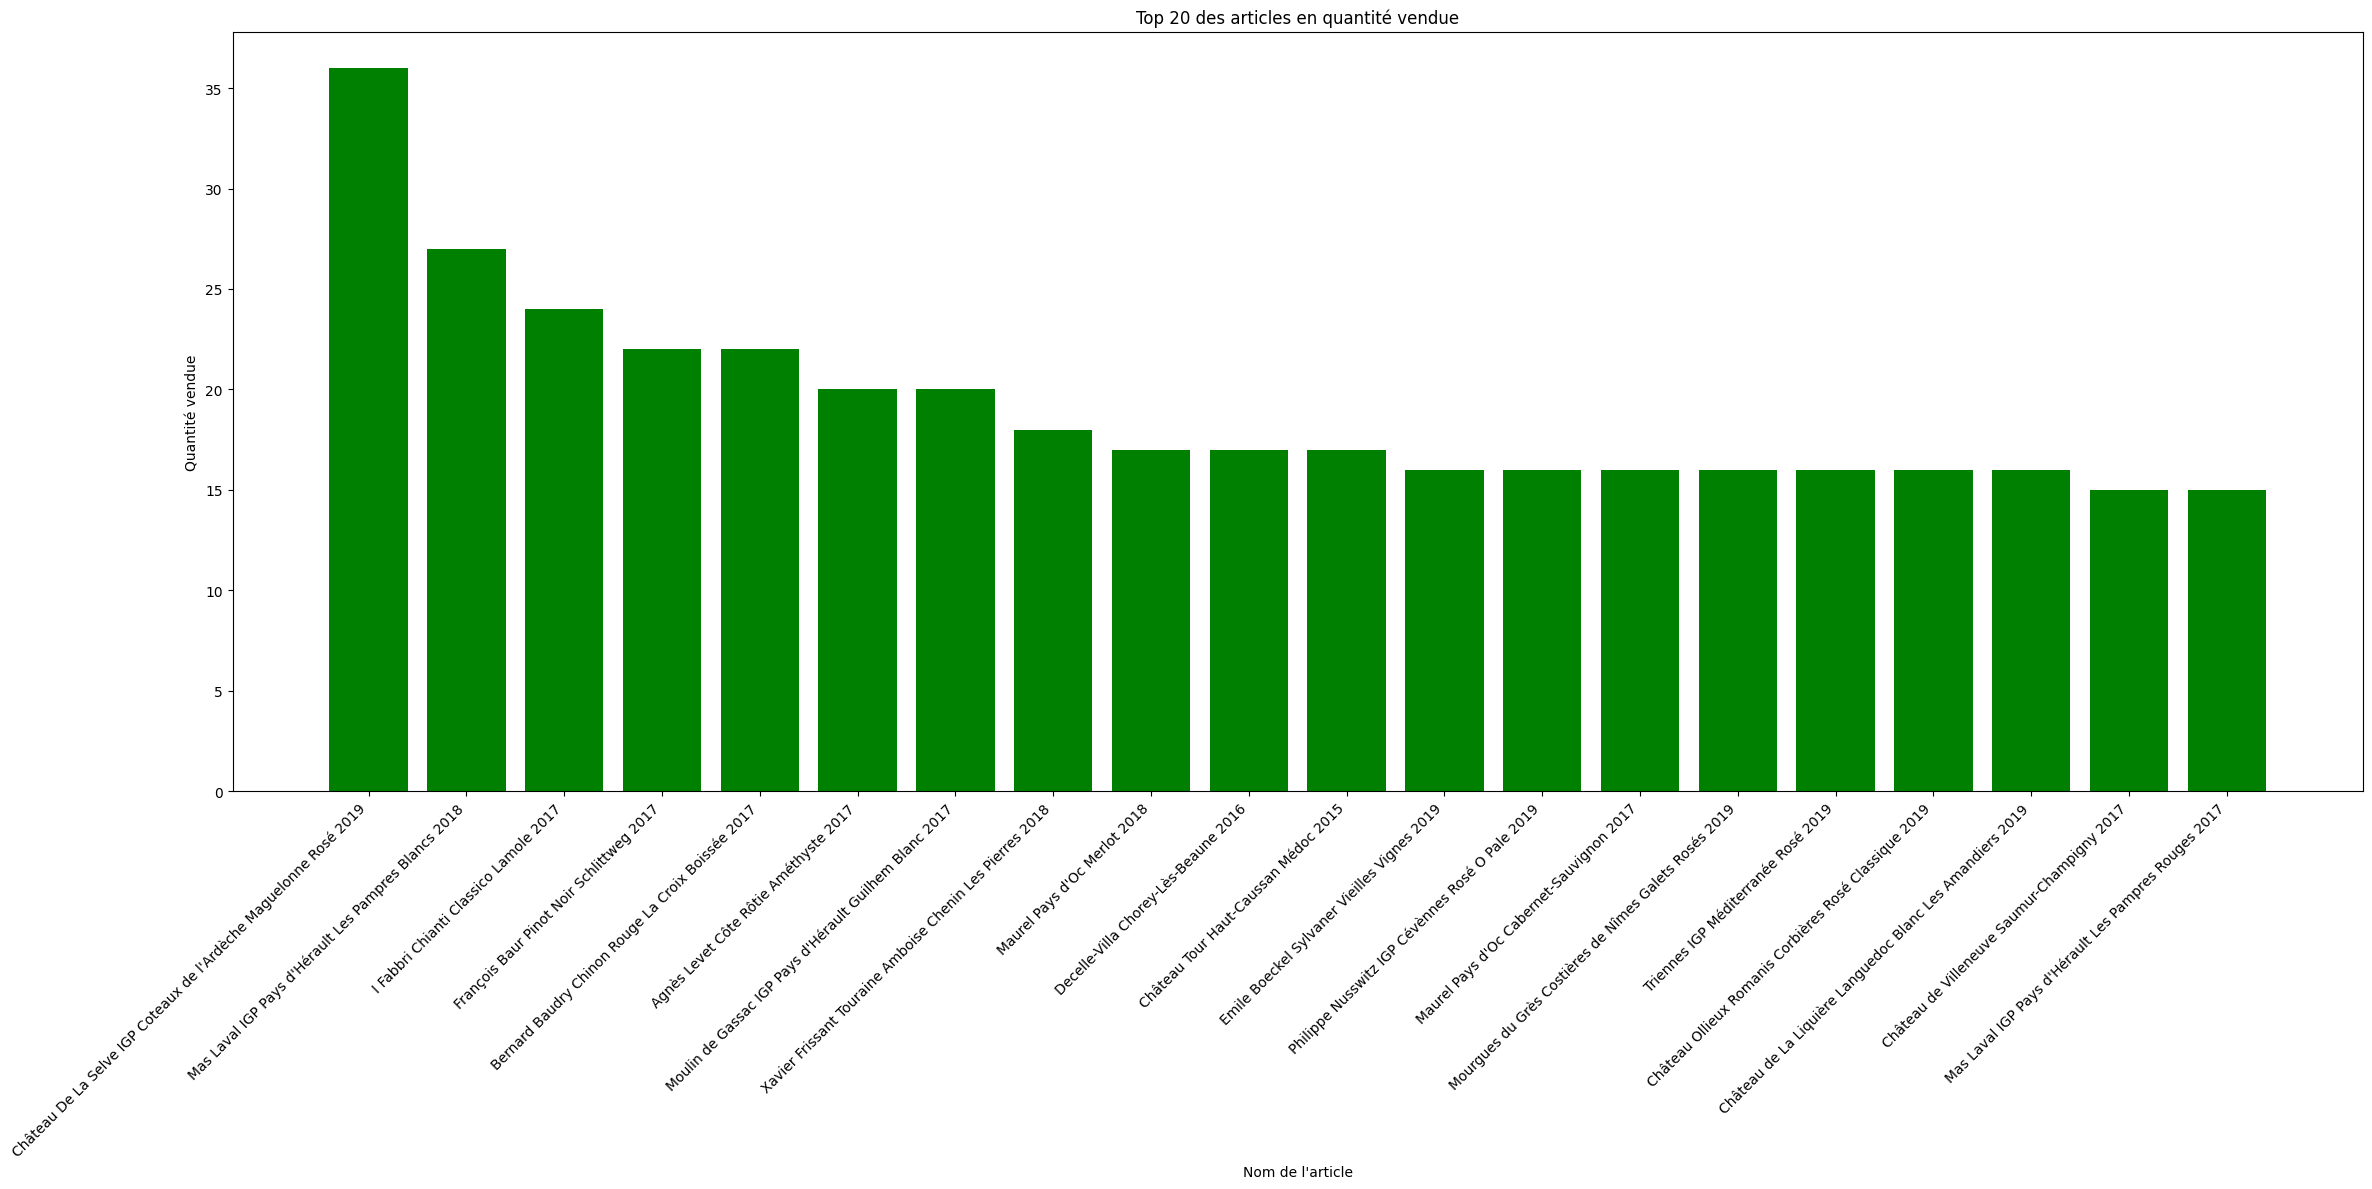

In [ ]:
#####################################
# Palmares des articles en quantité #
#####################################
# TODO Faire avec plotly express

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
#Réinitialiser l'index du dataset par un reset_index
df_merge_web_sort_vente = df_merge_web.sort_values(by='total_sales', ascending=False, na_position='last', ignore_index=True)
df_merge_web_sort_vente.dropna(subset=['total_sales'], inplace=True)
df_merge_web_sort_vente.dropna(subset=['post_title'], inplace=True)


#Afficher les 20 premier articles en quantité
top_20_sorts_vente =df_merge_web_sort_vente.head(20)
# display(top_20_sorts_vente)

#Graphique en barre des 20 premiers articles avec plotly express
names = top_20_sorts_vente['post_title']
values = top_20_sorts_vente['total_sales']
plt.figure(figsize=(24, 12))
plt.bar(names, values, color='green')
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 des articles en quantité vendue')
plt.xlabel('Nom de l\'article')
plt.ylabel('Quantité vendue')
plt.tight_layout()
plt.show()

In [ ]:
#############################
# Calculer le 20 / 80 en CA #
#############################
# Nombre de réf représentant 80% du CA: 424 articles
# Cela correspond à 51.27% du catalogue


#Créer une colonne calculant la part en quantité de la ligne dans le dataset
df_merge_web["quantité_proportion"] = (df_merge_web["stock_quantity"] / (df_merge_web["stock_quantity"].sum())) * 100

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_merge_web["quantité_prop_cumul"] = df_merge_web["quantité_proportion"].cumsum()

display(df_merge_web.head(5))
nbr_articles_1 = df_merge_web.count()
#Grâce au deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
nbr_articles_80_qte = df_merge_web[df_merge_web['quantité_prop_cumul']<= 80].count()
print(f"Le nombre d'articles représentant 80% des ventes en quantité est de {nbr_articles_80_qte['product_id']} articles")
#Afficher la proportion que représentent ce groupe d'articles dans le catalogue entier du site web
proportion_nbr_articles_80_qte = round((nbr_articles_80_qte['product_id'] / nbr_articles_1['product_id']) * 100, 2)
print(f"La proportion d'articles représentant 80% des ventes en quantité est de {proportion_nbr_articles_80_qte}%")

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,_merge,z_score_prix,ca_par_article,ca_proportion,ca_proportion_cumul,quantité_proportion,quantité_prop_cumul
0,4352.0,1.0,225.0,0.0,outofstock,137.81,15940,15940,0.0,0.0,0.0,0.0,11.0,taxable,2.0,2018-03-02 10:30:04,2018-03-02 09:30:04,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,Issu d’un assemblage de 70% de Pinot Noir du g...,publish,closed,closed,champagne-egly-ouriet-grand-cru-millesime-2008,2020-03-07 11:18:45,2020-03-07 10:18:45,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both,7.222548,2475.0,1.722577,1.722577,0.000000,0.000000
1,5892.0,1.0,191.3,98.0,instock,116.06,14983,14983,0.0,0.0,0.0,0.0,6.0,taxable,2.0,2019-03-28 10:21:36,2019-03-28 09:21:36,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,Cet Ambonnay évoque les grands Pinots Noirs de...,publish,closed,closed,coteaux-champenois-egly-ouriet-ambonnay-rouge-...,2020-04-01 09:30:09,2020-04-01 07:30:09,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both,5.960181,1147.8,0.798858,2.521435,0.550222,0.550222
2,4353.0,1.0,79.5,127.0,instock,45.91,12587,12587,0.0,0.0,0.0,0.0,14.0,taxable,2.0,2018-03-02 10:37:26,2018-03-02 09:37:26,Champagne,Champagne Egly-Ouriet Grand Cru Brut Rosé,&nbsp;\n\nLe Rosé Grand Cru de la maison Egly-...,publish,closed,closed,champagne-egly-ouriet-grand-cru-brut-rose,2020-08-22 11:45:02,2020-08-22 09:45:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both,1.772270,1113.0,0.774638,3.296072,0.713043,1.263264
3,5826.0,1.0,41.2,34.0,instock,21.71,15325,15325,0.0,0.0,0.0,0.0,20.0,taxable,2.0,2019-03-27 17:59:49,2019-03-27 16:59:49,Vin,Agnès Levet Côte Rôtie Améthyste 2017,"<span style=""float: none;background-color: tra...",publish,closed,closed,agnes-levet-amethyste-2017,2020-05-21 14:00:02,2020-05-21 12:00:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both,0.337591,824.0,0.573496,3.869569,0.190893,1.454158
4,6212.0,1.0,115.0,16.0,instock,59.42,13996,13996,0.0,0.0,0.0,0.0,7.0,taxable,2.0,2019-07-25 09:09:17,2019-07-25 07:09:17,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,"""Il s'agit là de la meilleure partie de l'appe...",publish,closed,closed,domaine-des-comtes-lafon-volnay-1er-cru-santen...,2020-06-16 09:30:16,2020-06-16 07:30:16,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both,3.102063,805.0,0.560272,4.429841,0.089832,1.543990


Le nombre d'articles représentant 80% des ventes en quantité est de 588 articles
La proportion d'articles représentant 80% des ventes en quantité est de 71.27%


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

/var/folders/jb/gy4cdzrd21j4lh00kfz13l3c0000gn/T/ipykernel_58303/157886359.py:13: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



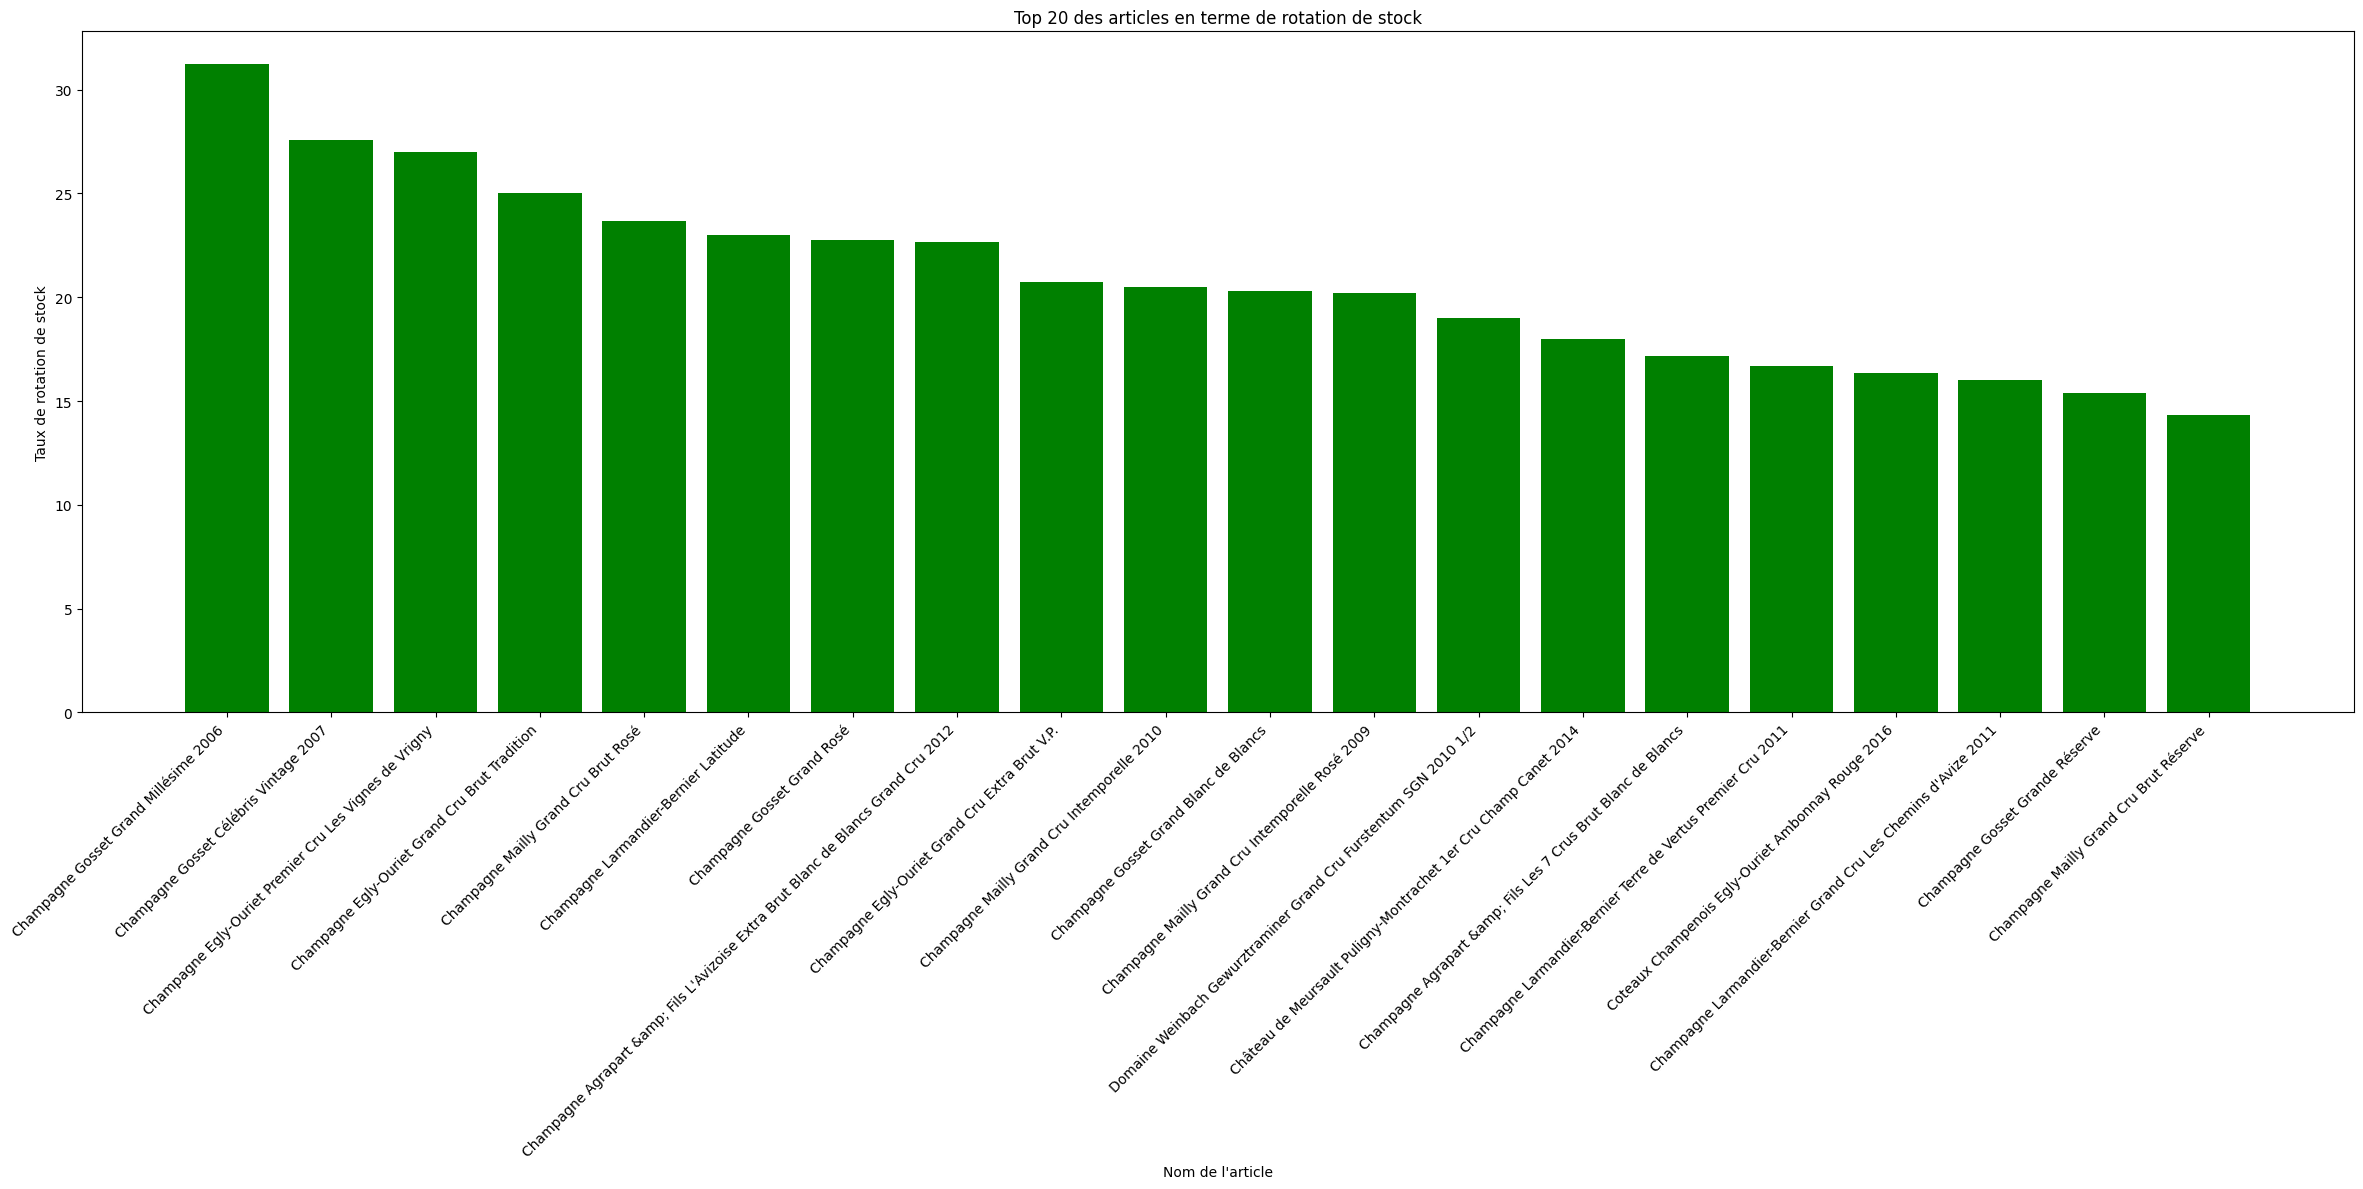

In [ ]:
######################################
# Calcule le nombre de mois de stock #
######################################

#Import de numpy 
import numpy as np

#Création de la colonne Rotation de stock

df_merge_web['rotation_stock'] = df_merge_web['stock_quantity'] / df_merge_web['total_sales'] 

#Remplacement des "inf" par 0
df_merge_web.replace([np.inf, -np.inf], 0, inplace=True)

#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge

df_merge_web_sort_stock = df_merge_web.sort_values(by='rotation_stock', ascending=False, na_position='last', ignore_index=True)

top_20_stock = df_merge_web_sort_stock.head(20)

#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock

names = top_20_stock['post_title']
values = top_20_stock['rotation_stock']
plt.figure(figsize=(24, 12))
plt.bar(names, values, color='green')
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 des articles en terme de rotation de stock')
plt.xlabel('Nom de l\'article')
plt.ylabel('Taux de rotation de stock')
plt.tight_layout()
plt.show()

In [ ]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
# méthode du coût unitaire moyen pondéré (CUMP)
df_merge_web['valorisation_stock_euros'] = df_merge_web['purchase_price'] * df_merge_web['stock_quantity']
df_merge_web.replace([np.inf, -np.inf], 0, inplace=True)

#Calculer la somme de la colonne "Valorisation_stock_euros"
valorisation_stock = round(df_merge_web['valorisation_stock_euros'].sum(), 2)

print(f"La valorisation des stocks en euros est de {valorisation_stock} Euros")

La valorisation des stocks en euros est de 298555.76 Euros


In [ ]:
##############################################
# Valorisation du nombre de produit en stock #
##############################################

#Calculer la somme de la colonne stock quantity
sum_stock_quantity = df_merge_web['stock_quantity'].sum()
print(f"Le nombre de produits en stock est de {sum_stock_quantity} articles")

Le nombre de produits en stock est de 17811.0 articles


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [ ]:
############################
# Analyse du taux de marge #
############################


#Création de la colonne prix HT
df_merge_web['prix_HT'] = df_merge_web['price'] / 1.2

df_merge_web['purchase_price_HT'] = df_merge_web['purchase_price'] / 1.2

#Création de la colonne Taux de marge
df_merge_web['taux_marge'] = (df_merge_web['prix_HT'] - df_merge_web['purchase_price_HT']) / df_merge_web['purchase_price_HT'] 
#Afficher le prix minimum de la colonne "taux_marge"
tx_marge_min = df_merge_web['taux_marge'].min()
display(tx_marge_min)
#Afficher le prix maximum de la colonne "taux_marge"
tx_marge_max= df_merge_web['taux_marge'].max()
display(tx_marge_max)


np.float64(-2.973969631236442)

np.float64(1.296949650863653)

In [ ]:
#affichage de la ligne avec un taux de marge inférieur à 0
tx_marge_negatif = df_merge_web[df_merge_web['taux_marge']<0]

display(tx_marge_negatif)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,_merge,z_score_prix,ca_par_article,ca_proportion,ca_proportion_cumul,quantité_proportion,quantité_prop_cumul,rotation_stock,valorisation_stock_euros,prix_HT,purchase_price_HT,taux_marge
692,4355.0,1.0,12.65,97.0,instock,77.48,12589,12589,0.0,0.0,0.0,0.0,0.0,taxable,2.0,2018-03-02 10:46:10,2018-03-02 09:46:10,Champagne,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,Le Blanc de Noirs représente le meilleur du sa...,publish,closed,closed,champagne-egly-ouriet-grand-cru-brut-blanc-de-...,2020-08-13 10:15:02,2020-08-13 08:15:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both,-0.731862,0.0,0.0,100.0,0.544607,93.908259,0.0,7515.56,10.541667,64.566667,-0.836732
719,4233.0,0.0,-20.00,0.0,outofstock,10.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only,-1.954897,NaN,NaN,NaN,0.000000,93.981248,NaN,0.00,-16.666667,8.608333,-2.936108
741,4864.0,0.0,8.30,0.0,outofstock,9.99,15154,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only,-0.894808,NaN,NaN,NaN,0.000000,94.340576,NaN,0.00,6.916667,8.325000,-0.169169
748,5017.0,0.0,-8.00,0.0,outofstock,4.34,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only,-1.505389,NaN,NaN,NaN,0.000000,94.284431,NaN,0.00,-6.666667,3.616667,-2.843318
769,6324.0,0.0,92.00,18.0,instock,99.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only,2.240507,NaN,NaN,NaN,0.101061,94.761664,NaN,1782.00,76.666667,82.500000,-0.070707
771,6594.0,0.0,-9.10,19.0,instock,4.61,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only,-1.546594,NaN,NaN,NaN,0.106676,94.868340,NaN,87.59,-7.583333,3.841667,-2.973970
819,7196.0,0.0,31.00,55.0,instock,31.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only,-0.044490,NaN,NaN,NaN,0.308798,99.567683,NaN,1716.00,25.833333,26.000000,-0.006410


In [ ]:
#création d'un dataframe avec les taux positifs
tx_marge_positif = df_merge_web[df_merge_web['taux_marge']>0]

#Afficher le prix minimum de la colonne "taux_marge"
tx_marge_min_positif = round(tx_marge_positif['taux_marge'].min(),2)
print(f'le prix minimum de la colonne "taux_marge est de {tx_marge_min_positif}')

#Afficher le prix maximum de la colonne "taux_marge"
tx_marge_max_positif = tx_marge_positif['taux_marge'].max()
print(f'le prix maximum de la colonne "taux_marge est de {tx_marge_max_positif}')

le prix minimum de la colonne "taux_marge est de 0.55
le prix maximum de la colonne "taux_marge est de 1.296949650863653


In [ ]:
#création d'un dataframe avec le taux de marge moyen par type de produit

df_merge_type_marge = df_merge_web.groupby('product_type')['taux_marge'].mean().reset_index()

#Affichage dans un graphique du taux de marge par type de produit
# TODO rajouter un graph en bar chart

fig = px.pie(df_merge_type_marge, values='taux_marge', names='product_type', color_discrete_sequence=px.colors.sequential.RdBu)
fig.show()


# version en bar
fig_bar = px.bar(
    df_merge_type_marge,
    x='product_type',
    y='taux_marge',
    title='Taux de marge par type de produit',
    labels={'product_type': 'Type de produit', 'taux_marge': 'Taux de marge'},
    color='product_type'  # couleurs différentes
)
fig_bar.update_layout(showlegend=False)
fig_bar.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des correlations entre les variables stock, sales et price</h3>
</div>

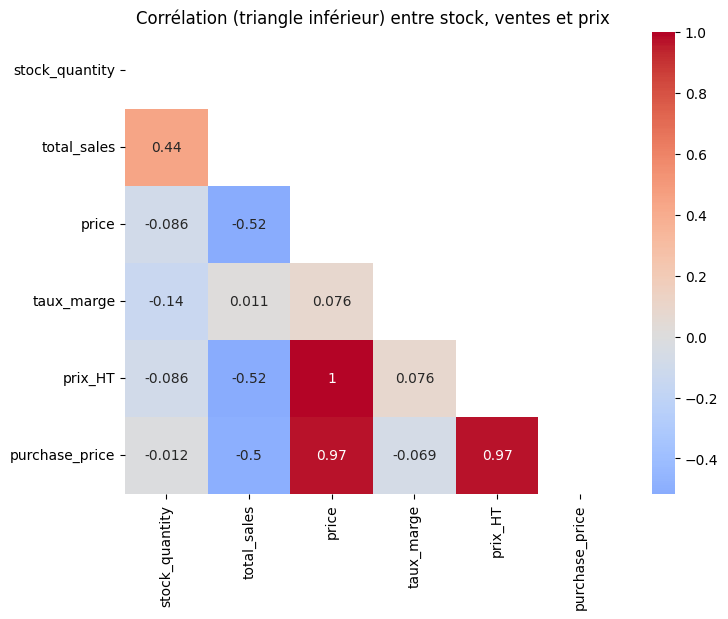

In [ ]:
############################
# Analyse des correlations #
############################

#Importation de Seaborn
import seaborn as sns


# Matrice de corrélation
corr = df_merge_web[['stock_quantity', 'total_sales', 'price', 'taux_marge', 'prix_HT', 'purchase_price']].corr()

# Masque pour la triangle supérieure
mask = np.triu(np.ones_like(corr, dtype=bool))
# Affichage de la heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, mask=mask, cmap='coolwarm', center=0)
plt.title('Corrélation (triangle inférieur) entre stock, ventes et prix')
plt.show()


<Axes: >

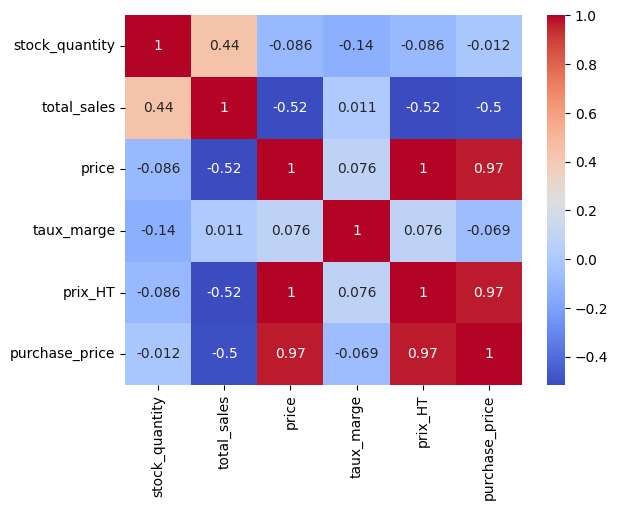

In [ ]:
df_merge_web_heat = df_merge_web[['stock_quantity', 'total_sales', 'price', 'taux_marge', 'prix_HT', 'purchase_price']]
sns.heatmap(df_merge_web_heat.corr(), annot=True, cmap='coolwarm')


In [ ]:
#Que peut-on conclure des correlations ?
print("Les ventes augmentent lorsqu'on a du stock et que le prix est bas")

Les ventes augmentent lorsqu'on a du stock et que le prix est bas


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mettre à disposition la nouvelle table sur un fichier Excel</h3>
</div>

In [ ]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut-être utile pour partager le résultat du dataset obtenu pour le partager avec les équipes.  

df_merge_web.to_excel("df_merge_web.xlsx", index=False)